#### TODO:
* split features into raw and t-series (impute as raw, and fillna -1 or 0 for t-series?)
* hypertuning
* add demographic parameters (and string params e.g. ett)
* check feature importance
* (add time series features - covariance? And feature interactions?)
* add feature selection using mlxtend SFS
* trial new sampling/training regime
* include non rfd patients
* improve class size balancing so that we retain all NRFD instances for patients who were declared fit for discharge but had a negative outcome - these are the harder cases, and they are currently being diluted by the other NRFD instances (from earlier in stays).

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.pipeline import Pipeline
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
%matplotlib inline

In [2]:
FILLNA = False
FILLNA_VAL = 0

In [3]:
project_name = 'smartt_bmj_open_plus'

In [4]:
save_to_path = Path(f"E:/SMARTT/data/processed/{project_name}")

In [5]:
final_cohort = pd.read_json('..\data\processed\linked_cohort_181024.json', convert_dates=['admitStoreDateTime', 'dischargeStoreDateTime'])

In [6]:
all_samples = pd.read_csv(save_to_path / f"all_24hr_samples_final_cohort_.csv", low_memory=False)

In [7]:
original_features = [
    'Glasgow Coma Scale_ffill', 'temperature_ffill', 'arterial blood pressure (mean)_ffill', 'Fio2_ffill',
    'arterial oxygen saturation_ffill', 'respiratory rate_ffill', 'Heart rate_ffill', 'actual bicarbonate_ffill',
    'Hemoglobin_ffill', 'platelet count_ffill', 'Sodium_ffill', 'potassium_ffill',
    'creatinine_ffill', 'urea_ffill', 'Bilirubin_ffill', 'positive end-expiratory pressure_ffill', 'hours_since_admission'
]

In [8]:
new_features = [
    c
    for c in all_samples.columns
    if '_ffill' in c and c not in original_features and 'trach' not in c and 'delta' not in c
]

In [9]:
temporal_features = [
    c
    for c in all_samples.columns
    if 'delta' in c
]

In [10]:
all_features = original_features + new_features + temporal_features

In [11]:
all_samples['label'] = [s in ['True', '1', 1] for s in all_samples['label']]

In [12]:
for f in all_samples[original_features + ['hours_since_admission', 'eid'] + new_features + temporal_features]:
    all_samples[f] = pd.to_numeric(all_samples[f], errors='coerce')

In [13]:
 all_samples = all_samples[
     ['time', 'hours_since_admission', 'label', 'eid']
     + all_features
]
# ].dropna()

In [14]:
NNeigh = 5
imputer = KNNImputer(n_neighbors=NNeigh)

In [15]:
impute_features = all_features #original_features + new_features
all_samples.loc[:,impute_features] = imputer.fit_transform(all_samples[impute_features])

In [16]:
if FILLNA:
    all_samples.loc[:,temporal_features] = all_samples[temporal_features].fillna(FILLNA_VAL, inplace=False)

In [17]:
all_samples.groupby('label').count()

,time,hours_since_admission,eid,Glasgow Coma Scale_ffill,temperature_ffill,arterial blood pressure (mean)_ffill,Fio2_ffill,arterial oxygen saturation_ffill,respiratory rate_ffill,Heart rate_ffill,...,creatinine_ffill_delta_3,urea_ffill_delta_1,urea_ffill_delta_2,urea_ffill_delta_3,Bilirubin_ffill_delta_1,Bilirubin_ffill_delta_2,Bilirubin_ffill_delta_3,positive end-expiratory pressure_ffill_delta_1,positive end-expiratory pressure_ffill_delta_2,positive end-expiratory pressure_ffill_delta_3
label,,,,,,,,,,,,,,,,,,,,,
False,16796,16807,16796,16807,16807,16807,16807,16807,16807,16807,...,16807,16807,16807,16807,16807,16807,16807,16807,16807,16807
True,4129,4129,4129,4129,4129,4129,4129,4129,4129,4129,...,4129,4129,4129,4129,4129,4129,4129,4129,4129,4129


In [18]:
scaler = StandardScaler()

In [19]:
scaled_samples = all_samples.copy()
# scaled_samples[original_features] = scaler.fit_transform(scaled_samples[original_features])
scaled_samples[all_features] = scaler.fit_transform(scaled_samples[all_features])

In [20]:
desired_class_size = len(scaled_samples[scaled_samples.label==1])

In [21]:
scaled_samples = pd.concat([
    scaled_samples[scaled_samples.label==1],
    scaled_samples[scaled_samples.label==0].sample(n=desired_class_size)
])

In [22]:
train, test = train_test_split(final_cohort[final_cohort['Declared clinically ready for discharge']=='Yes'], test_size=0.2)

In [23]:
# train, test = train_test_split(scaled_samples, test_size=0.2)
train = scaled_samples[scaled_samples.eid.isin(train.encounterId)]
test = scaled_samples[scaled_samples.eid.isin(test.encounterId)]

In [24]:
lr_features = original_features
rf_features = original_features
nrf_features = all_features

In [25]:
rf_grid_space ={
    'max_depth': [3, 5, 10, None],
    'n_estimators': [10, 100, 200],
    'max_features': [3, 5, 7, 'sqrt', None],
    'min_samples_leaf': [1, 2, 3],
    'min_samples_split': [2, 3, 5],
}

In [26]:
# clf = RandomForestClassifier(random_state=0).fit(
#     train[original_features],
#     train['label'],
# )
clf = GridSearchCV(RandomForestClassifier(), param_grid=rf_grid_space, cv=5, scoring='accuracy', verbose=2, n_jobs=-1).fit(
    train[rf_features],
    train['label'],
)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits


In [27]:
clf.score(
    test[rf_features],
    test['label']
)

0.8239355581127733

In [28]:
# nclf = RandomForestClassifier(random_state=0).fit(
#     train[original_features + new_features],
#     train['label'],
# )
nclf = GridSearchCV(RandomForestClassifier(), param_grid=rf_grid_space, cv=5, scoring='accuracy', verbose=2, n_jobs=-1).fit(
    train[nrf_features],
    train['label'],
)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits


In [29]:
nclf.score(
    test[nrf_features],
    test['label']
)

0.8429228998849252

In [30]:
lr_clf = LogisticRegression(random_state=0).fit(
    train[lr_features],
    train['label'],
)

In [31]:
lr_clf.score(
    test[lr_features],
    test['label']
)

0.80897583429229

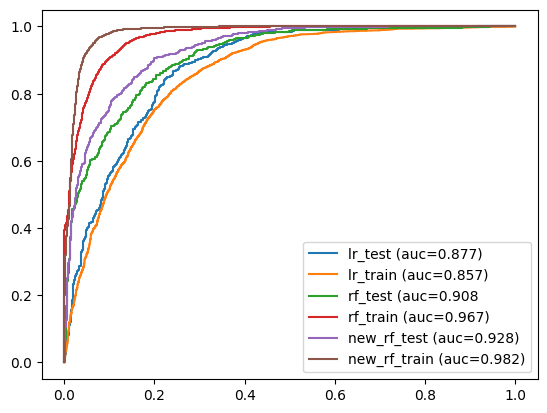

In [32]:
lr_features = original_features

fpr, tpr, thresholds = roc_curve(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1]
)
plt.plot(fpr, tpr, label=f"lr_test (auc={auc:.3f})")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    lr_clf.predict_proba(train[lr_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    lr_clf.predict_proba(train[lr_features])[:,1]
)
plt.plot(fpr, tpr, label=f"lr_train (auc={auc:.3f})")

## RF:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"rf_test (auc={auc:.3f}")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    clf.predict_proba(train[rf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    clf.predict_proba(train[rf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"rf_train (auc={auc:.3f})")


## New RF:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    nclf.predict_proba(test[nrf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    nclf.predict_proba(test[nrf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"new_rf_test (auc={auc:.3f})")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    nclf.predict_proba(train[nrf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    nclf.predict_proba(train[nrf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"new_rf_train (auc={auc:.3f})")


plt.legend();

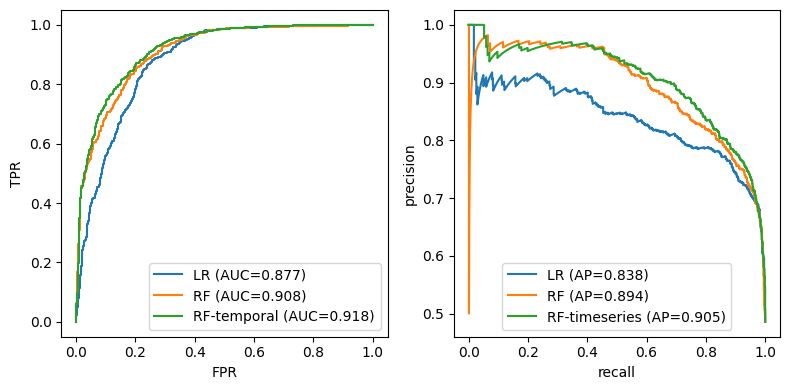

In [44]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
fpr, tpr, thresholds = roc_curve(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1]
)
plt.plot(fpr, tpr, label=f"LR (AUC={auc:.3f})")

## RF:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1]
)
plt.plot(fpr, tpr, label=f"RF (AUC={auc:.3f})")

## New RF:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    rfc2.predict_proba(test[selected_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    rfc2.predict_proba(test[selected_features])[:,1]
)
# fpr, tpr, thresholds = roc_curve(
#     test['label'],
#     nclf.predict_proba(test[nrf_features])[:,1],
#     pos_label=1
# )
# auc = roc_auc_score(
#     test['label'],
#     nclf.predict_proba(test[nrf_features])[:,1]
# )
plt.plot(fpr, tpr, label=f"RF-temporal (AUC={auc:.3f})")
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend();
################# PRC
plt.subplot(1,2,2)
precision, recall, thresholds = precision_recall_curve(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1],
    pos_label=1
)
auc = average_precision_score(
    test['label'],
    lr_clf.predict_proba(test[lr_features])[:,1]
)
plt.plot(recall, precision, label=f"LR (AP={auc:.3f})")

## RF:
precision, recall, thresholds = precision_recall_curve(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1],
    pos_label=1
)
auc = average_precision_score(
    test['label'],
    clf.predict_proba(test[rf_features])[:,1]
)
plt.plot(recall, precision, label=f"RF (AP={auc:.3f})")

## New RF:
precision, recall, thresholds = precision_recall_curve(
    test['label'],
    rfc2.predict_proba(test[selected_features])[:,1],
    pos_label=1
)
auc = average_precision_score(
    test['label'],
    rfc2.predict_proba(test[selected_features])[:,1]
)
# precision, recall, thresholds = precision_recall_curve(
#     test['label'],
#     nclf.predict_proba(test[nrf_features])[:,1],
#     pos_label=1
# )
# auc = average_precision_score(
#     test['label'],
#     nclf.predict_proba(test[nrf_features])[:,1]
# )
plt.plot(recall, precision, label=f"RF-timeseries (AP={auc:.3f})")
plt.xlabel('recall')
plt.ylabel('precision')
plt.legend();
plt.tight_layout()

In [34]:
len(all_features)

76

In [35]:
nclf.best_params_

{'max_depth': 10,
 'max_features': 3,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 200}

In [36]:
rfc1 = RandomForestClassifier(**nclf.best_params_)
rfc2 = RandomForestClassifier(**nclf.best_params_)

In [37]:
sfs1 = SFS(
    estimator=rfc1,
    k_features=(10,55),
    forward=True, 
    floating=False,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

In [38]:
sfs1.fit(
    train[nrf_features],
    train['label'],
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  60 out of  77 | elapsed:    9.9s remaining:    2.7s
[Parallel(n_jobs=-1)]: Done  77 out of  77 | elapsed:   11.8s finished
Features: 1/55[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  58 out of  76 | elapsed:   11.0s remaining:    3.3s
[Parallel(n_jobs=-1)]: Done  76 out of  76 | elapsed:   13.3s finished
Features: 2/55[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  56 out of  75 | elapsed:   19.6s remaining:    6.6s
[Parallel(n_jobs=-1)]: Done  75 out of  75 | elapsed:   21.7s finished
Features: 3/55[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  54 out of  74 | elapsed:   20.3s remaining:    7.4s
[Parallel(n_jobs=-1)]: Done  74 out of  74 | elapsed:   22.3s finished
Features: 4/55[Parallel(n_jobs=-1)]: Using

SequentialFeatureSelector(estimator=RandomForestClassifier(max_depth=10,
                                                           max_features=3,
                                                           min_samples_leaf=2,
                                                           n_estimators=200),
                          k_features=(10, 55), n_jobs=-1, scoring='accuracy',
                          verbose=1)

In [39]:
selected_features = [all_features[f] for f in sfs1.k_feature_idx_]
print(selected_features)
len(selected_features)

['Glasgow Coma Scale_ffill', 'arterial oxygen saturation_ffill', 'respiratory rate_ffill', 'platelet count_ffill', 'Bilirubin_ffill', 'hours_since_admission', 'arterial blood pressure (systolic)_ffill', 'arterial blood pressure (diastolic)_ffill', 'noninvasive blood pressure (diastolic)_ffill', 'Pao2/Fio2_ffill', 'temperature_ffill_delta_2', 'arterial blood pressure (mean)_ffill_delta_1', 'arterial blood pressure (mean)_ffill_delta_2', 'arterial blood pressure (mean)_ffill_delta_3', 'Fio2_ffill_delta_1', 'Fio2_ffill_delta_2', 'respiratory rate_ffill_delta_2', 'Hemoglobin_ffill_delta_2', 'platelet count_ffill_delta_1', 'platelet count_ffill_delta_2', 'Sodium_ffill_delta_1', 'Sodium_ffill_delta_2', 'potassium_ffill_delta_1', 'creatinine_ffill_delta_2']


24

In [40]:
sfs1.k_score_

np.float64(0.8231509625126646)

In [41]:
sfs1.get_metric_dict()

{1: {'feature_idx': (0,),
  'cv_scores': array([0.71753986, 0.7388003 , 0.74924012, 0.72340426, 0.69528875]),
  'avg_score': np.float64(0.724854659549081),
  'feature_names': ('Glasgow Coma Scale_ffill',),
  'ci_bound': np.float64(0.02383086342801329),
  'std_dev': np.float64(0.01854122136680723),
  'std_err': np.float64(0.009270610683403615)},
 2: {'feature_idx': (0, 16),
  'cv_scores': array([0.75170843, 0.77069096, 0.78115502, 0.75227964, 0.69300912]),
  'avg_score': np.float64(0.7497686323111613),
  'feature_names': ('Glasgow Coma Scale_ffill', 'hours_since_admission'),
  'ci_bound': np.float64(0.03921531636085474),
  'std_dev': np.float64(0.03051084841354409),
  'std_err': np.float64(0.015255424206772044)},
 3: {'feature_idx': (0, 16, 35),
  'cv_scores': array([0.76613516, 0.78587699, 0.80319149, 0.76291793, 0.72720365]),
  'avg_score': np.float64(0.7690650437463795),
  'feature_names': ('Glasgow Coma Scale_ffill',
   'hours_since_admission',
   'arterial blood pressure (mean)_ffi

In [42]:
# nclf = RandomForestClassifier(random_state=0).fit(
#     train[original_features + new_features],
#     train['label'],
# )
rfc2 = GridSearchCV(RandomForestClassifier(), param_grid=rf_grid_space, cv=5, scoring='accuracy', verbose=2, n_jobs=-1).fit(
    train[selected_features],
    train['label'],
)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits


C:\Users\mcwilliamschr\Documents\SMARTT\sniffer_release\SMARTTDataExtraction\newenv\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [43]:
rfc2.score(
    test[selected_features],
    test['label']
)

0.8296892980437284

#### This is like the example given in the documentation, but seems wrong to me and is very slow!:

In [ ]:
pipe = Pipeline([
    ('sfs', sfs1),
    ('rf', rfc2)
])

In [ ]:
param_grid ={
    'sfs__k_features': [10, 15, 20, 25, 30, 35],
    'sfs__estimator__max_depth': [3, 5, 10, None],
    'sfs__estimator__n_estimators': [10, 100, 200],
    'sfs__estimator__max_features': [3, 5, 7, 'sqrt', None],
    'sfs__estimator__min_samples_leaf': [1, 2, 3],
    'sfs__estimator__min_samples_split': [2, 3, 5],
    'rf__max_depth': [3, 5, 10, None],
    'rf__n_estimators': [10, 100, 200, 500],
    'rf__max_features': [3, 5, 7, 'sqrt', None],
    'rf__min_samples_leaf': [1, 2, 3],
    'rf__min_samples_split': [2, 3, 5],
}

In [ ]:
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

In [ ]:
gs.fit(
    train[original_features + new_features],
    train['label'],
)

In [ ]:
gs.get_params()

In [ ]:
lr_features = all_features

fpr, tpr, thresholds = roc_curve(
    test['label'],
    gs.predict_proba(test[lr_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    gs.predict_proba(test[lr_features])[:,1]
)
plt.plot(fpr, tpr, label=f"lr_test (auc={auc:.3f})")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    gs.predict_proba(train[lr_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    gs.predict_proba(train[lr_features])[:,1]
)
plt.plot(fpr, tpr, label=f"lr_train (auc={auc:.3f})")

## RF:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    clf.predict_proba(test[original_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    clf.predict_proba(test[original_features])[:,1]
)
plt.plot(fpr, tpr, label=f"rf_test (auc={auc:.3f}")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    clf.predict_proba(train[original_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    clf.predict_proba(train[original_features])[:,1]
)
plt.plot(fpr, tpr, label=f"rf_train (auc={auc:.3f})")


## New RF:
fpr, tpr, thresholds = roc_curve(
    test['label'],
    nclf.predict_proba(test[original_features + new_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    test['label'],
    nclf.predict_proba(test[original_features + new_features])[:,1]
)
plt.plot(fpr, tpr, label=f"new_rf_test (auc={auc:.3f})")

fpr, tpr, thresholds = roc_curve(
    train['label'],
    nclf.predict_proba(train[original_features + new_features])[:,1],
    pos_label=1
)
auc = roc_auc_score(
    train['label'],
    nclf.predict_proba(train[original_features + new_features])[:,1]
)
plt.plot(fpr, tpr, label=f"new_rf_train (auc={auc:.3f})")


plt.legend();


#### We now test the classifiers on the cohort subset that were not declared RFD.

There are two groups:
* those with positive outcomes, who are assigned label 1 at the end of their stay, but who may have been ready earlier,
* those with negative outcomes, who are assigned label 0 throughout. Adn we therefore hope for a low false positive rate (although they are not reflected in training).

We should also look at the NRFD instances for patients who were declared fit for discharge but had a negative outcoem - these should be harder cases for the classifier.